# Early Stopping With Progression Data

This notebook shows the Ax 0.4.3 early-stopping flow using:

- `support_intermediate_data=True`
- `update_running_trial_with_intermediate_data(...)`
- `should_stop_trials_early(...)`

The example uses manual curves so the stop decision is easy to inspect.


In [1]:
import warnings
import matplotlib.pyplot as plt
import pandas as pd
from ax.early_stopping.strategies.percentile import PercentileEarlyStoppingStrategy
from ax.service.ax_client import AxClient, ObjectiveProperties

warnings.filterwarnings("ignore", message=".*DataFrame concatenation with empty or all-NA entries is deprecated.*")

client = AxClient(
    random_seed=0,
    enforce_sequential_optimization=False,
    verbose_logging=False,
    early_stopping_strategy=PercentileEarlyStoppingStrategy(
        metric_names=["score"],
        percentile_threshold=50.0,
        min_progression=2,
        min_curves=2,
    ),
)
client.create_experiment(
    parameters=[
        {"name": "x", "type": "range", "bounds": [0.0, 1.0], "value_type": "float"},
    ],
    objectives={"score": ObjectiveProperties(minimize=False)},
    support_intermediate_data=True,
)

def add_curve(client, x, curve, complete=False):
    _, trial_index = client.attach_trial({"x": x})
    intermediate = [
        ({"step": step}, {"score": (value, 0.0)})
        for step, value in curve[:-1]
    ]
    if intermediate:
        client.update_running_trial_with_intermediate_data(trial_index, intermediate)
    final_step, final_value = curve[-1]
    if complete:
        client.complete_trial(trial_index, [({"step": final_step}, {"score": (final_value, 0.0)})])
    else:
        client.update_running_trial_with_intermediate_data(
            trial_index,
            [({"step": final_step}, {"score": (final_value, 0.0)})],
        )
    return trial_index

good_1 = add_curve(client, 0.90, [(1, 0.60), (2, 0.80), (3, 0.90), (4, 1.00)], complete=True)
good_2 = add_curve(client, 0.80, [(1, 0.55), (2, 0.75), (3, 0.85), (4, 0.95)], complete=True)
weak = add_curve(client, 0.20, [(1, 0.10), (2, 0.15), (3, 0.20)], complete=False)
borderline = add_curve(client, 0.70, [(1, 0.50), (2, 0.70), (3, 0.82)], complete=False)

decisions = client.should_stop_trials_early({weak, borderline})
map_df = client.experiment.fetch_data().map_df.copy()

print("Early-stop decisions:")
decisions


[WARNING 03-17 12:05:45] ax.service.utils.with_db_settings_base: Ax currently requires a sqlalchemy version below 2.0. This will be addressed in a future release. Disabling SQL storage in Ax for now, if you would like to use SQL storage please install Ax with mysql extras via `pip install ax-platform[mysql]`.
[WARNING 03-17 12:05:45] ax.service.ax_client: Random seed set to 0. Note that this setting only affects the Sobol quasi-random generator and BoTorch-powered Bayesian optimization models. For the latter models, setting random seed to the same number for two optimizations will make the generated trials similar, but not exactly the same, and over time the trials will diverge more.
[INFO 03-17 12:05:45] ax.service.utils.instantiation: Created search space: SearchSpace(parameters=[RangeParameter(name='x', parameter_type=FLOAT, range=[0.0, 1.0])], parameter_constraints=[]).
[INFO 03-17 12:05:45] ax.modelbridge.dispatch_utils: Using Models.BOTORCH_MODULAR since there is at least one ord

Early-stop decisions:


{2: 'Trial objective value 0.2 is worse than 50.0-th percentile (0.835) across comparable trials.',
 3: 'Trial objective value 0.82 is worse than 50.0-th percentile (0.835) across comparable trials.'}

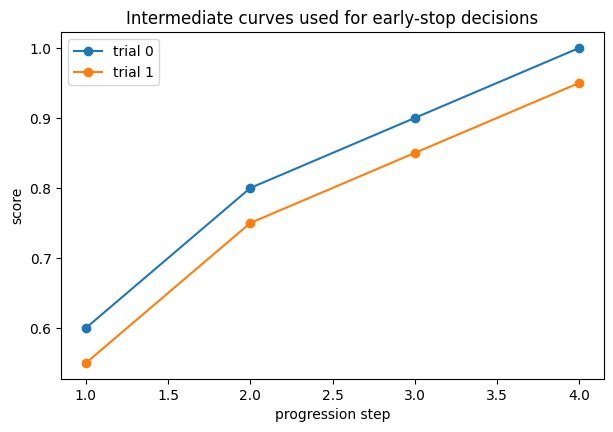

In [2]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for trial_index, trial_df in map_df.groupby("trial_index"):
    ax.plot(trial_df["step"], trial_df["mean"], marker="o", label=f"trial {trial_index}")

ax.set_xlabel("progression step")
ax.set_ylabel("score")
ax.set_title("Intermediate curves used for early-stop decisions")
ax.legend()
plt.show()


In [3]:
for trial_index in decisions:
    client.stop_trial_early(trial_index)

status_summary = {
    trial_index: trial.status.name
    for trial_index, trial in client.experiment.trials.items()
}
status_summary


{0: 'COMPLETED', 1: 'COMPLETED', 2: 'EARLY_STOPPED', 3: 'EARLY_STOPPED'}

## Version Caveat

In Ax 0.4.3, `estimate_early_stopping_savings()` expects a `MapMetric`
implementation when it tries to infer the progression key automatically.
This notebook focuses on the stop/no-stop decision itself, which is the
main integration point for CEID.
